#### `Solving a quadratic equation using langgraph graphs to understand conditional workflows`

In [ ]:
# required imports
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [ ]:
# defining the state structure for the quadratic equation workflow
class QuadState(TypedDict):
    a: int
    b: int
    c: int

    equation: str
    discriminant: int
    results: str

In [ ]:
# defining the functions for each step in the workflow

# 1. Show the equation
def show_equation(state: QuadState):

    b_sign = '+' if state['b'] >= 0 else '-'
    c_sign = '+' if state['c'] >= 0 else '-'

    equation = f'{state["a"]}x\u00B2 {b_sign} {abs(state["b"])}x {c_sign} {abs(state["c"])} = 0'

    return {'equation' : equation}


#3. Calculate the discriminant
def calculate_discriminant(state: QuadState):

    discriminant = state['b']**2 - 4*state['a']*state['c']

    return {'discriminant' : discriminant}


# 4. Check the discriminant and calculate the roots accordingly
def real_roots(state: QuadState):

    root1 = (-state['b'] + state['discriminant']**0.5) / (2*state['a'])
    root2 = (-state['b'] - state['discriminant']**0.5) / (2*state['a'])

    result = f'The roots are {root1} and {root2}'

    return {'results' : result}


def repeated_roots(state: QuadState):

    root = (-state['b'] / (2*state['a']))

    result = f'The only repeating root is {root}'

    return {'results' : result}


def no_real_roots(state: QuadState):

    return {'results' : 'No real roots exist'}

# 5. Check the discriminant and route to the appropriate node
def check_discriminant(state: QuadState) -> Literal['Real Roots', 'Repeated Roots', 'No Real Roots']:

    if state['discriminant'] > 0:
        return 'Real Roots'
    elif state['discriminant'] == 0:
        return 'Repeated Roots'
    else:
        return 'No Real Roots'


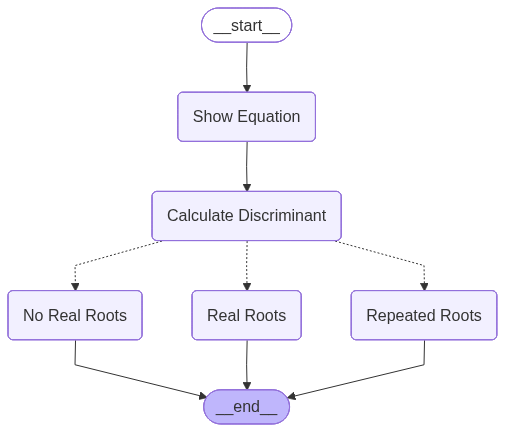

In [ ]:
# creating the state graph and adding nodes and edges
graph = StateGraph(QuadState)

# nodes
graph.add_node('Show Equation', show_equation)
graph.add_node('Calculate Discriminant', calculate_discriminant)
graph.add_node('Real Roots', real_roots)
graph.add_node('Repeated Roots', repeated_roots)
graph.add_node('No Real Roots', no_real_roots)

# edges
graph.add_edge(START, 'Show Equation')
graph.add_edge('Show Equation', 'Calculate Discriminant')

# conditional edges based on the value of the discriminant
graph.add_conditional_edges('Calculate Discriminant', check_discriminant)
graph.add_edge('Real Roots', END)
graph.add_edge('Repeated Roots', END)
graph.add_edge('No Real Roots', END)

# compiling the workflow and visualizing it
workflow = graph.compile()
workflow



In [47]:
initial_state = {
    'a' : 2,
    'b' : 4,
    'c' : 2
}
workflow.invoke(initial_state)

{'a': 2,
 'b': 4,
 'c': 2,
 'equation': '2x² + 4x + 2 = 0',
 'discriminant': 0,
 'results': 'The only repeating root is -1.0'}

In [48]:
workflow.invoke({
    'a' : 1,
    'b' : -3,
    'c' : 2
    })

{'a': 1,
 'b': -3,
 'c': 2,
 'equation': '1x² - 3x + 2 = 0',
 'discriminant': 1,
 'results': 'The roots are 2.0 and 1.0'}

In [49]:
workflow.invoke({
    'a' : 2,
    'b' : 2,
    'c' : 4
    })

{'a': 2,
 'b': 2,
 'c': 4,
 'equation': '2x² + 2x + 4 = 0',
 'discriminant': -28,
 'results': 'No real roots exist'}